In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import time

from sklearn.preprocessing import LabelEncoder
from data_load_utils import load_image, load_data, create_data_frame

import PIL
from PIL import Image

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [2]:
from torchvision.models import ResNet50_Weights

## Loading & Preparing Data for ResNet50

In [3]:
training_dir = "./data/train"
testing_dir = "./data/test"

In [4]:
weights = ResNet50_Weights.IMAGENET1K_V2

In [5]:
transform = weights.transforms()

In [6]:
train_dataset = ImageFolder(root=training_dir, transform=transform)

In [7]:
labels = [label for _, label in train_dataset.samples]

In [8]:
counts = {}
for label in labels:
    try:
        counts[label] += 1
    except:
        counts[label] = 1    

In [9]:
class_weights = [v for v in counts.values()]

In [10]:
class_weights

[3995, 436, 4097, 7215, 4965, 4830, 3171]

In [11]:
sample_weights = [0] *len(train_dataset)

In [12]:
for i, (data, label) in enumerate(train_dataset):
    class_weight = class_weights[label]
    sample_weights[i] = class_weight

In [13]:
sampler = WeightedRandomSampler(sample_weights, num_samples = len(sample_weights), replacement = True)

In [14]:
train_loader = DataLoader(train_dataset, batch_size = 10, sampler = sampler)

Inspecting Training Data Distribution

In [18]:
from collections import Counter

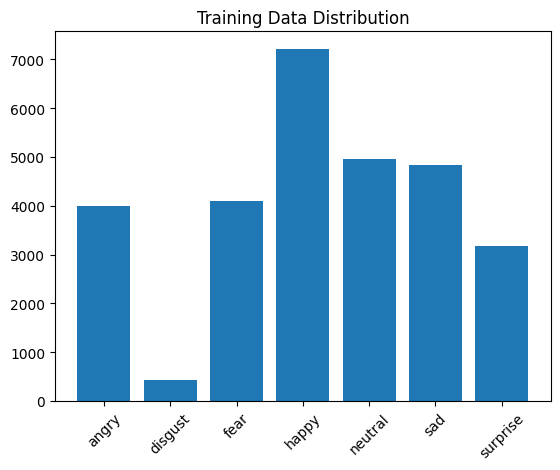

In [25]:
names = train_dataset.classes
counts = [class_counts[i] for i in range(len(names))]

plt.bar(names, counts)
plt.title("Training Data Distribution")
plt.xticks(rotation=45)
plt.savefig("./graphics/Training_Data_Distribution")
plt.show()

## Loading & Training ResNet50

In [16]:
model = torchvision.models.resnet50(weights = weights, progress = True)

In [23]:
for param in model.parameters():
    param.requires_grad = False

In [24]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [25]:
num_ftrs = model.fc.in_features

In [26]:
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 1024),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 7)
    ) 


In [27]:
model = model.to("cuda")

In [28]:
criterion = nn.CrossEntropyLoss().to("cuda")
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [29]:
losses = []
scores = {}
epoch_count = 0

In [43]:
epochs = 20

start_time = time.time()

for epoch in range(epochs):
    model.train()
    corrects = 0
    wrongs = 0 
    running_loss = 0
    for b, (X_train, y_train) in enumerate(train_loader):
        X_train = X_train.to("cuda")
        y_train = y_train.to("cuda")
        batch = b+1
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.argmax(y_pred, dim = 1)

        corrects += (predicted == y_train).sum().item()
        wrongs += (predicted != y_train).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if b%100 == 0:
            print(f"Epoch: {epoch}/{epochs} Batch: {batch} Current Loss: {running_loss/batch}")
    
    scores[epoch_count] = {
        "corrects": corrects,
        "wrongs": wrongs,
        "accuracy": corrects/(wrongs+corrects),
        "loss": running_loss/batch
    }
    epoch_count += 1
    print(f"Epoch: {epoch}. Current Accuracy: {corrects/(wrongs+corrects)}")
    losses.append(running_loss/batch)

end_time = time.time()
total_time = (end_time-start_time)/60
print(f"Training took {total_time} minutes")
        

Epoch: 0/20 Batch: 1 Current Loss: 1.7999303340911865
Epoch: 0/20 Batch: 101 Current Loss: 1.4986775428941934
Epoch: 0/20 Batch: 201 Current Loss: 1.5238274534543355
Epoch: 0/20 Batch: 301 Current Loss: 1.5118168598393664
Epoch: 0/20 Batch: 401 Current Loss: 1.49642139242177
Epoch: 0/20 Batch: 501 Current Loss: 1.4919700024132718
Epoch: 0/20 Batch: 601 Current Loss: 1.4811931764226587
Epoch: 0/20 Batch: 701 Current Loss: 1.4809681743425922
Epoch: 0/20 Batch: 801 Current Loss: 1.4819097711650024
Epoch: 0/20 Batch: 901 Current Loss: 1.4818160689366644
Epoch: 0/20 Batch: 1001 Current Loss: 1.4789412643287803
Epoch: 0/20 Batch: 1101 Current Loss: 1.4787076534627244
Epoch: 0/20 Batch: 1201 Current Loss: 1.4809416006943468
Epoch: 0/20 Batch: 1301 Current Loss: 1.4792970072572549
Epoch: 0/20 Batch: 1401 Current Loss: 1.4766763217273906
Epoch: 0/20 Batch: 1501 Current Loss: 1.4743640697216844
Epoch: 0/20 Batch: 1601 Current Loss: 1.4756784329259491
Epoch: 0/20 Batch: 1701 Current Loss: 1.47633

In [61]:
#Saving Model
torch.save(model, "./models/resnet50_complex_last_layer_weighed_classes.pth")

In [62]:
#Saving Model Params in order to make continued training possible
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, "./models/resnet50_complex_last_layer_weighed_classes_checkpoint.pth")

In [63]:
#Saving Scores Dict in order to keep track of model improvements in case of continued training
with open("./models/resnet_50_complex_last_layer_weighed_classes_scores.pkl", "wb") as f:
    pickle.dump(scores, f)

In [44]:
accuracies = []
for v in scores.values():
    accuracies.append(v["accuracy"])

In [45]:
accuracies

[0.3987948030234421,
 0.431049496673517,
 0.45275000870807064,
 0.45574558500818557,
 0.4571737085931241,
 0.467553728795848,
 0.4704448082482845,
 0.4774460970427392,
 0.4713504475948309,
 0.4785955623672019,
 0.48221811975338746,
 0.4798146922567836,
 0.4822529520359469,
 0.48291476540457695,
 0.4834372496429691,
 0.49047337071998326,
 0.4936431084328956,
 0.49165766832700547,
 0.4931206241945035,
 0.4956633808213452,
 0.4947229091922394]

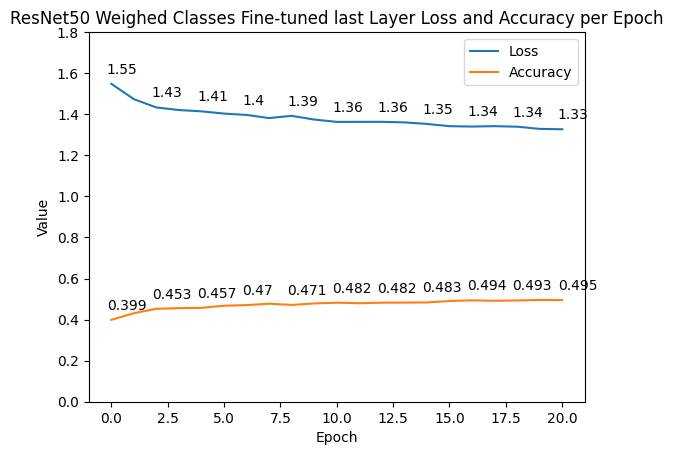

In [60]:
plt.plot(range(len(losses)), losses, label = "Loss")
plt.plot(range(len(accuracies)), accuracies, label = "Accuracy")
for i, v in enumerate(losses):
    if i%2 == 0:
        plt.text(i -0.2, v+0.05, f"{v:.3}")

for i, v in enumerate(accuracies):
    if i%2 == 0:
        plt.text(i-0.2, v+0.05, f"{v:.3}")
plt.ylim(0,1.8)
plt.legend()
plt.title("ResNet50 Weighed Classes Fine-tuned last Layer Loss and Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.savefig("./graphics/ResNet50_complex_last_layer_weighted_classes_Loss_Accuracy")
plt.show()

## Evaluating on testing Data

In [48]:
testing_data = ImageFolder(root = testing_dir, transform = transform)

In [49]:
testing_data.samples[0]

('./data/test\\angry\\PrivateTest_10131363.jpg', 0)

In [50]:
testing_loader = DataLoader(testing_data, batch_size = 10, shuffle = False)

In [51]:
predictions = []

In [52]:
model.eval()
with torch.no_grad():
    for X_test, y_test in testing_loader:
        X_test = X_test.to("cuda")
        y_test = y_test.to("cuda")
        y_pred = model(X_test)
        preds = torch.argmax(y_pred, dim = 1)
        predictions.extend(preds)
        

In [53]:
actual = [label for _, label in testing_data]

In [54]:
len(actual)

7178

In [55]:
preds = [p.item() for p in predictions]

In [56]:
len(predictions)

7178

In [57]:
corrects = 0
for i, v in enumerate(preds):
    if v == actual[i]:
        corrects += 1

In [58]:
corrects/len(actual)

0.3967679019225411